# Modelagem de Sobrevida - LUSC

In [138]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter, WeibullAFTFitter
from lifelines.utils import concordance_index
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

In [139]:
try:
    import torch
    import torchtuples as tt

    from pycox.models import CoxPH, DeepHitSingle
    from pycox.evaluation import EvalSurv

    deep_ok = True

except Exception as e:
    deep_ok = False
    print(e)

In [140]:
cohort = "LUSC"

project_dir = Path("..").resolve()

data_path = project_dir / "data" / "processed" / "lusc" / "lusc_modeling_dataset.csv"

results_dir = project_dir / "reports" / "results" / "lusc"
figures_dir = project_dir / "reports" / "figures" / "lusc"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

time_col = "surv__OS.time"
event_col = "surv__OS"

seed = 42
n_splits = 5

In [141]:
print(data_path)

df = pd.read_csv(data_path, sep=";")

print("Shape:", df.shape)
df.head()

/workspaces/An-lise-de-Sobrevida/data/processed/lusc/lusc_modeling_dataset.csv
Shape: (494, 61)


,patient_id,surv__OS.time,surv__OS,clin__age_at_initial_pathologic_diagnosis,clin__number_pack_years_smoked,clin__tobacco_smoking_history,clin__age_at_initial_pathologic_diagnosis_missing,clin__number_pack_years_smoked_missing,clin__tobacco_smoking_history_missing,clin__gender_bin,...,GCGR,F13A1,ACVRL1,MDH1,SEMA3B,ZNF71,FGF4,GAGE2A,SLC39A8,SOX2
0,TCGA-18-3406,371.0,1,67.0,200.0,4.0,0,0,0,1,...,4.0659,10.0489,9.0286,13.0819,4.7113,8.0951,0.0000,0.0000,10.4514,8.4698
1,TCGA-18-3407,136.0,1,72.0,40.0,3.0,0,0,0,1,...,3.5193,8.2571,8.9985,12.0345,6.8297,5.6575,0.0000,3.9771,10.3928,12.2245
2,TCGA-18-3408,2304.0,1,77.0,30.0,4.0,0,0,0,0,...,0.0000,11.7268,8.2709,12.4069,3.6172,5.5986,0.6719,0.0000,10.1578,13.3835
3,TCGA-18-3409,3747.0,0,74.0,20.0,3.0,0,0,0,1,...,2.7314,10.7797,9.7230,11.6099,10.1626,7.9463,0.0000,0.0000,9.7864,5.2450
4,TCGA-18-3410,146.0,1,81.0,0.0,3.0,0,1,0,1,...,1.1255,8.6900,10.2864,11.8564,4.2569,8.5270,0.0000,0.0000,9.5320,9.3927


In [142]:
if "patient_id" in df.columns:
    patient_ids = df["patient_id"].copy()
    df = df.drop(columns=["patient_id"])
else:
    patient_ids = pd.Series(range(len(df)), name="patient_id")

In [143]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Total de nulos:", int(df.isna().sum().sum()))

nulos = df.isna().sum().sort_values(ascending=False)
nulos[nulos > 0].head(30)

Total de nulos: 0


Series([], dtype: int64)

In [144]:
df[event_col] = df[event_col].astype(int)
df[time_col] = df[time_col].astype(float)

print(df[event_col].value_counts())

print( round(df[event_col].mean() * 100, 2), "%")

print("Mínimo:", df[time_col].min())
print("Mediana:", df[time_col].median())
print("Máximo:", df[time_col].max())

surv__OS
0    282
1    212
Name: count, dtype: int64
42.91 %
Mínimo: 1.0
Mediana: 663.0
Máximo: 5287.0


In [145]:
feature_cols = [
    c for c in df.columns
    if c not in [time_col, event_col]
]

feature_cols = [
    c for c in feature_cols
    if "vital_status" not in c.lower()
]

X = df[feature_cols].copy()
tempo = df[time_col].copy()
evento = df[event_col].copy()

In [146]:
skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=seed
)

folds = list(skf.split(X, evento))

print(len(folds))

for i, (train_idx, test_idx) in enumerate(folds, start=1):
    print(
        f"Fold {i}:",
        "treino =", len(train_idx),
        "| teste =", len(test_idx),
        "| eventos teste =", int(evento.iloc[test_idx].sum())
    )

5
Fold 1: treino = 395 | teste = 99 | eventos teste = 43
Fold 2: treino = 395 | teste = 99 | eventos teste = 43
Fold 3: treino = 395 | teste = 99 | eventos teste = 42
Fold 4: treino = 395 | teste = 99 | eventos teste = 42
Fold 5: treino = 396 | teste = 98 | eventos teste = 42


## Pré-processamento nos folds

In [147]:
def tirar_baixa_variancia(X_train, X_test, threshold=0.01):
    seletor = VarianceThreshold(threshold=threshold)

    X_train_sel = seletor.fit_transform(X_train)
    X_test_sel = seletor.transform(X_test)

    colunas = X_train.columns[seletor.get_support()]

    X_train_sel = pd.DataFrame(X_train_sel, columns=colunas, index=X_train.index)
    X_test_sel = pd.DataFrame(X_test_sel, columns=colunas, index=X_test.index)

    return X_train_sel, X_test_sel

In [148]:
def tirar_colinearidade(X_train, X_test, limite=0.90):
    corr = X_train.corr().abs()

    matriz_superior = corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )

    colunas_remover = [
        col for col in matriz_superior.columns
        if any(matriz_superior[col] > limite)
    ]

    X_train_ok = X_train.drop(columns=colunas_remover, errors="ignore")
    X_test_ok = X_test.drop(columns=colunas_remover, errors="ignore")

    return X_train_ok, X_test_ok, colunas_remover

In [149]:
def padronizar_dados(X_train, X_test):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(
        X_train_scaled,
        columns=X_train.columns,
        index=X_train.index
    )

    X_test_scaled = pd.DataFrame(
        X_test_scaled,
        columns=X_test.columns,
        index=X_test.index
    )

    return X_train_scaled, X_test_scaled

In [150]:
def preparar_fold(X_train, X_test, usar_scaler=True, var_threshold=0.01, corr_threshold=0.90):
    X_train_prep, X_test_prep = tirar_baixa_variancia(
        X_train,
        X_test,
        threshold=var_threshold
    )

    X_train_prep, X_test_prep, removidas_corr = tirar_colinearidade(
        X_train_prep,
        X_test_prep,
        limite=corr_threshold
    )

    if usar_scaler:
        X_train_prep, X_test_prep = padronizar_dados(
            X_train_prep,
            X_test_prep
        )

    return X_train_prep, X_test_prep, removidas_corr

In [151]:
def criar_y_sksurv(tempo_parte, evento_parte):
    return Surv.from_arrays(
        event=evento_parte.astype(bool).values,
        time=tempo_parte.astype(float).values
    )

In [152]:
resultados_folds = []
resumo_modelos = []

def guardar_resultado(modelo, fold, c_train, c_test):
    resultados_folds.append({
        "modelo": modelo,
        "fold": fold,
        "c_index_train": c_train,
        "c_index_test": c_test,
        "gap": c_train - c_test
    })


def criar_resumo_modelo(nome_modelo):
    temp = pd.DataFrame(resultados_folds)
    temp = temp[temp["modelo"] == nome_modelo]

    resumo = {
        "modelo": nome_modelo,
        "c_index_treino_medio": temp["c_index_train"].mean(),
        "c_index_teste_medio": temp["c_index_test"].mean(),
        "dp_teste": temp["c_index_test"].std(),
        "gap_medio": temp["gap"].mean()
    }

    resumo_modelos.append(resumo)

    return pd.DataFrame([resumo])

## Modelo 1 - Cox Proportional Hazards

In [153]:
nome_modelo = "CoxPH"

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"{nome_modelo} - {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx]
    tempo_test = tempo.iloc[test_idx]

    evento_train = evento.iloc[train_idx]
    evento_test = evento.iloc[test_idx]

    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=True,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    df_train = X_train_prep.copy()
    df_train[time_col] = tempo_train.values
    df_train[event_col] = evento_train.values

    cox = CoxPHFitter(penalizer=1.0)
    cox.fit(df_train, duration_col=time_col, event_col=event_col)

    risco_train = cox.predict_partial_hazard(X_train_prep)
    risco_test = cox.predict_partial_hazard(X_test_prep)

    c_train = concordance_index(tempo_train, -risco_train, evento_train)
    c_test = concordance_index(tempo_test, -risco_test, evento_test)

    guardar_resultado(nome_modelo, fold, c_train, c_test)

    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))

CoxPH - 1


C-index treino: 0.7013
C-index teste: 0.6155
CoxPH - 2
C-index treino: 0.6861
C-index teste: 0.6838
CoxPH - 3
C-index treino: 0.7101
C-index teste: 0.5183
CoxPH - 4
C-index treino: 0.6912
C-index teste: 0.6274
CoxPH - 5
C-index treino: 0.6747
C-index teste: 0.7281


In [154]:
resumo_cox = criar_resumo_modelo("CoxPH")
resumo_cox

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,CoxPH,0.692687,0.634625,0.079214,0.058062


## Modelo 2 - Weibull AFT

In [155]:
nome_modelo = "Weibull AFT"

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"{nome_modelo} - {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx]
    tempo_test = tempo.iloc[test_idx]

    evento_train = evento.iloc[train_idx]
    evento_test = evento.iloc[test_idx]

    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=True,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    df_train = X_train_prep.copy()
    df_train[time_col] = tempo_train.values
    df_train[event_col] = evento_train.values

    aft = WeibullAFTFitter(penalizer=1.0)
    aft.fit(df_train, duration_col=time_col, event_col=event_col)

    pred_train = aft.predict_median(X_train_prep)
    pred_test = aft.predict_median(X_test_prep)

    pred_train = pred_train.replace([np.inf, -np.inf], np.nan)
    pred_test = pred_test.replace([np.inf, -np.inf], np.nan)

    pred_train = pred_train.fillna(pred_train.max())
    pred_test = pred_test.fillna(pred_test.max())

    c_train = concordance_index(tempo_train, pred_train, evento_train)
    c_test = concordance_index(tempo_test, pred_test, evento_test)

    guardar_resultado(nome_modelo, fold, c_train, c_test)
    
    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))

Weibull AFT - 1


C-index treino: 0.6996
C-index teste: 0.6141
Weibull AFT - 2
C-index treino: 0.6857
C-index teste: 0.6788
Weibull AFT - 3
C-index treino: 0.7104
C-index teste: 0.5201
Weibull AFT - 4
C-index treino: 0.6911
C-index teste: 0.6231
Weibull AFT - 5
C-index treino: 0.6727
C-index teste: 0.7212


In [156]:
resumo_weibull = criar_resumo_modelo("Weibull AFT")
resumo_weibull

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,Weibull AFT,0.691905,0.631467,0.075942,0.060437


## Modelo 3 - Random Survival Forest

In [157]:
nome_modelo = "RSF"

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"{nome_modelo} - {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx]
    tempo_test = tempo.iloc[test_idx]

    evento_train = evento.iloc[train_idx]
    evento_test = evento.iloc[test_idx]

    # Para árvore, não precisa scaler
    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=False,
        var_threshold=0.01,
        corr_threshold=0.95
    )

    y_train = criar_y_sksurv(tempo_train, evento_train)

    rsf = RandomSurvivalForest(
        n_estimators=200,
        min_samples_split=20,
        min_samples_leaf=15,
        max_features="sqrt",
        max_depth=10,
        n_jobs=-1,
        random_state=seed
    )

    rsf.fit(X_train_prep, y_train)

    risco_train = rsf.predict(X_train_prep)
    risco_test = rsf.predict(X_test_prep)

    c_train = concordance_index_censored(
        evento_train.astype(bool),
        tempo_train,
        risco_train
    )[0]

    c_test = concordance_index_censored(
        evento_test.astype(bool),
        tempo_test,
        risco_test
    )[0]

    guardar_resultado(nome_modelo, fold, c_train, c_test)
    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))

RSF - 1


C-index treino: 0.8015
C-index teste: 0.6004
RSF - 2
C-index treino: 0.7971
C-index teste: 0.6251
RSF - 3
C-index treino: 0.7896
C-index teste: 0.5492
RSF - 4
C-index treino: 0.8063
C-index teste: 0.5802
RSF - 5
C-index treino: 0.7837
C-index teste: 0.7168


In [158]:
resumo_rsf = criar_resumo_modelo("RSF")
resumo_rsf

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,RSF,0.795642,0.614319,0.063651,0.181323


## Modelo 4 - Gradient Boosting Survival Analysis

In [159]:
nome_modelo = "GBSA"

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"{nome_modelo} - {fold}")

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx]
    tempo_test = tempo.iloc[test_idx]

    evento_train = evento.iloc[train_idx]
    evento_test = evento.iloc[test_idx]

    # Para árvore, não precisa scaler
    X_train_prep, X_test_prep, removidas_corr = preparar_fold(
        X_train,
        X_test,
        usar_scaler=False,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    y_train = criar_y_sksurv(tempo_train, evento_train)

    gbsa = GradientBoostingSurvivalAnalysis(
        n_estimators=100,
        learning_rate=0.02,
        max_depth=1,
        subsample=0.7,
        random_state=seed
    )

    gbsa.fit(X_train_prep, y_train)

    risco_train = gbsa.predict(X_train_prep)
    risco_test = gbsa.predict(X_test_prep)

    c_train = concordance_index_censored(
        evento_train.astype(bool),
        tempo_train,
        risco_train
    )[0]

    c_test = concordance_index_censored(
        evento_test.astype(bool),
        tempo_test,
        risco_test
    )[0]

    guardar_resultado(nome_modelo, fold, c_train, c_test)


    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))

GBSA - 1
C-index treino: 0.6778
C-index teste: 0.5341
GBSA - 2
C-index treino: 0.6718
C-index teste: 0.5508
GBSA - 3
C-index treino: 0.6667
C-index teste: 0.5185
GBSA - 4
C-index treino: 0.6874
C-index teste: 0.5489
GBSA - 5
C-index treino: 0.6674
C-index teste: 0.6678


In [160]:
resumo_gbsa = criar_resumo_modelo("GBSA")
resumo_gbsa

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,GBSA,0.674224,0.564043,0.059456,0.110181


## Modelo 5 - DeepSurv

In [161]:
def preparar_dados_deep(X_train, X_test):
    X_train_deep = X_train.astype("float32").values
    X_test_deep = X_test.astype("float32").values

    return X_train_deep, X_test_deep

In [162]:
if deep_ok:
    nome_modelo = "DeepSurv"

    for fold, (train_idx, test_idx) in enumerate(folds, start=1):
        print(f"\nRodando {nome_modelo} - Fold {fold}")

        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()

        tempo_train = tempo.iloc[train_idx].astype("float32")
        tempo_test = tempo.iloc[test_idx].astype("float32")

        evento_train = evento.iloc[train_idx].astype("float32")
        evento_test = evento.iloc[test_idx].astype("float32")

        X_train_prep, X_test_prep, removidas_corr = preparar_fold(
            X_train,
            X_test,
            usar_scaler=True,
            var_threshold=0.01,
            corr_threshold=0.90
        )

        x_train_deep, x_test_deep = preparar_dados_deep(
            X_train_prep,
            X_test_prep
        )

        in_features = x_train_deep.shape[1]

        net = tt.practical.MLPVanilla(
            in_features=in_features,
            num_nodes=[32, 16],
            out_features=1,
            batch_norm=True,
            dropout=0.1
        )

        model = CoxPH(
            net,
            tt.optim.Adam
        )

        model.optimizer.set_lr(0.001)

        callbacks = [
            tt.callbacks.EarlyStopping(patience=10)
        ]

        model.fit(
            x_train_deep,
            (tempo_train.values, evento_train.values),
            batch_size=32,
            epochs=100,
            callbacks=callbacks,
            val_data=(x_test_deep, (tempo_test.values, evento_test.values)),
            verbose=False
        )

        model.compute_baseline_hazards(
            input=x_train_deep,
            target=(tempo_train.values, evento_train.values)
        )

        surv_train = model.predict_surv_df(x_train_deep)
        surv_test = model.predict_surv_df(x_test_deep)

        ev_train = EvalSurv(
            surv_train,
            tempo_train.values,
            evento_train.values,
            censor_surv="km"
        )

        ev_test = EvalSurv(
            surv_test,
            tempo_test.values,
            evento_test.values,
            censor_surv="km"
        )

        c_train = ev_train.concordance_td("antolini")
        c_test = ev_test.concordance_td("antolini")

        guardar_resultado(nome_modelo, fold, c_train, c_test)

        print("C-index treino:", round(c_train, 4))
        print("C-index teste:", round(c_test, 4))


Rodando DeepSurv - Fold 1


C-index treino: 0.754
C-index teste: 0.58

Rodando DeepSurv - Fold 2
C-index treino: 0.6989
C-index teste: 0.5965

Rodando DeepSurv - Fold 3
C-index treino: 0.7231
C-index teste: 0.4155

Rodando DeepSurv - Fold 4
C-index treino: 0.6911
C-index teste: 0.6112

Rodando DeepSurv - Fold 5
C-index treino: 0.7617
C-index teste: 0.6218


In [163]:
resumo_deepsurv = criar_resumo_modelo("DeepSurv")
resumo_deepsurv

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,DeepSurv,0.725771,0.565015,0.085078,0.160755


## Modelo 6 - DeepHit

In [164]:
if deep_ok:
    nome_modelo = "DeepHit"

    num_durations = 30

    for fold, (train_idx, test_idx) in enumerate(folds, start=1):
        print(f" {nome_modelo} - {fold}")

        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()

        tempo_train = tempo.iloc[train_idx].astype("float32")
        tempo_test = tempo.iloc[test_idx].astype("float32")

        evento_train = evento.iloc[train_idx].astype("int64")
        evento_test = evento.iloc[test_idx].astype("int64")

        X_train_prep, X_test_prep, removidas_corr = preparar_fold(
            X_train,
            X_test,
            usar_scaler=True,
            var_threshold=0.01,
            corr_threshold=0.90
        )

        x_train_deep, x_test_deep = preparar_dados_deep(
            X_train_prep,
            X_test_prep
        )

        labtrans = DeepHitSingle.label_transform(num_durations)

        y_train = labtrans.fit_transform(
            tempo_train.values,
            evento_train.values
        )

        y_test = labtrans.transform(
            tempo_test.values,
            evento_test.values
        )

        in_features = x_train_deep.shape[1]
        out_features = labtrans.out_features

        net = tt.practical.MLPVanilla(
            in_features=in_features,
            num_nodes=[32, 16],
            out_features=out_features,
            batch_norm=True,
            dropout=0.1
        )

        model = DeepHitSingle(
            net,
            tt.optim.Adam,
            alpha=0.5,
            sigma=0.1,
            duration_index=labtrans.cuts
        )

        model.optimizer.set_lr(0.001)

        callbacks = [
            tt.callbacks.EarlyStopping(patience=10)
        ]

        model.fit(
            x_train_deep,
            y_train,
            batch_size=32,
            epochs=200,
            callbacks=callbacks,
            val_data=(x_test_deep, y_test),
            verbose=False
        )

        surv_train = model.predict_surv_df(x_train_deep)
        surv_test = model.predict_surv_df(x_test_deep)

        ev_train = EvalSurv(
            surv_train,
            tempo_train.values,
            evento_train.values,
            censor_surv="km"
        )

        ev_test = EvalSurv(
            surv_test,
            tempo_test.values,
            evento_test.values,
            censor_surv="km"
        )

        c_train = ev_train.concordance_td("antolini")
        c_test = ev_test.concordance_td("antolini")

        guardar_resultado(nome_modelo, fold, c_train, c_test)

        print("C-index treino:", round(c_train, 4))
        print("C-index teste:", round(c_test, 4))

 DeepHit - 1


C-index treino: 0.513
C-index teste: 0.5336
 DeepHit - 2
C-index treino: 0.6011
C-index teste: 0.5655
 DeepHit - 3
C-index treino: 0.5974
C-index teste: 0.5002
 DeepHit - 4
C-index treino: 0.5704
C-index teste: 0.5398
 DeepHit - 5
C-index treino: 0.6294
C-index teste: 0.5299


In [165]:
if deep_ok:
    resumo_deephit = criar_resumo_modelo("DeepHit")
    resumo_deephit

In [166]:
df_resultados_folds = pd.DataFrame(resultados_folds)

df_resultados_folds

df_resultados_folds.to_csv(
    results_dir / "lusc_resultados_por_fold.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print(results_dir / "lusc_resultados_por_fold.csv")

/workspaces/An-lise-de-Sobrevida/reports/results/lusc/lusc_resultados_por_fold.csv


In [167]:
df_resumo_modelos = pd.DataFrame(resumo_modelos)

df_resumo_modelos = df_resumo_modelos.sort_values(
    "c_index_teste_medio",
    ascending=False
).reset_index(drop=True)

df_resumo_modelos

df_resumo_modelos.to_csv(
    results_dir / "lusc_resumo_modelos.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print( results_dir / "lusc_resumo_modelos.csv")

/workspaces/An-lise-de-Sobrevida/reports/results/lusc/lusc_resumo_modelos.csv


In [168]:
tabela_tcc = df_resumo_modelos.copy()

colunas_num = [
    "c_index_treino_medio",
    "c_index_teste_medio",
    "dp_teste",
    "gap_medio"
]

for col in colunas_num:
    tabela_tcc[col] = tabela_tcc[col].round(4)

tabela_tcc

,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,CoxPH,0.6927,0.6346,0.0792,0.0581
1,Weibull AFT,0.6919,0.6315,0.0759,0.0604
2,RSF,0.7956,0.6143,0.0637,0.1813
3,DeepSurv,0.7258,0.5650,0.0851,0.1608
4,GBSA,0.6742,0.5640,0.0595,0.1102
5,DeepHit,0.5823,0.5338,0.0234,0.0485


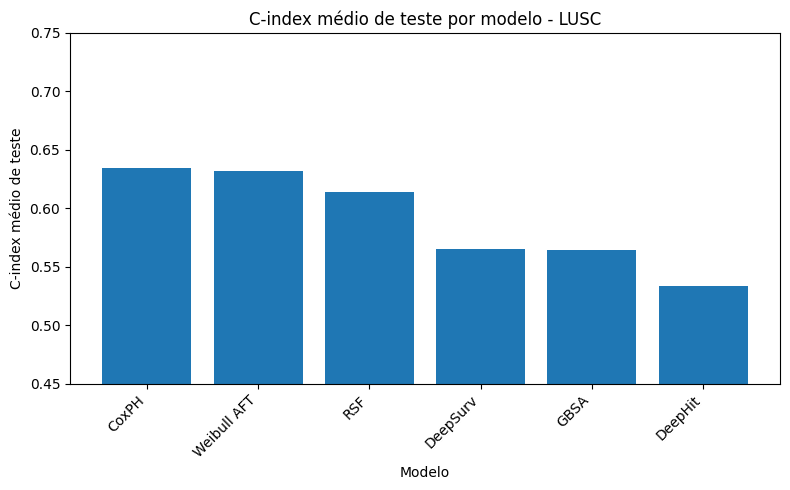

/workspaces/An-lise-de-Sobrevida/reports/figures/lusc/lusc_cindex_modelos.png


In [169]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    tabela_tcc["modelo"],
    tabela_tcc["c_index_teste_medio"]
)

ax.set_title("C-index médio de teste por modelo - LUSC")
ax.set_xlabel("Modelo")
ax.set_ylabel("C-index médio de teste")
ax.set_ylim(0.45, 0.75)

plt.xticks(rotation=45, ha="right")

fig.tight_layout()

fig.savefig(
    figures_dir / "lusc_cindex_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print( figures_dir / "lusc_cindex_modelos.png")

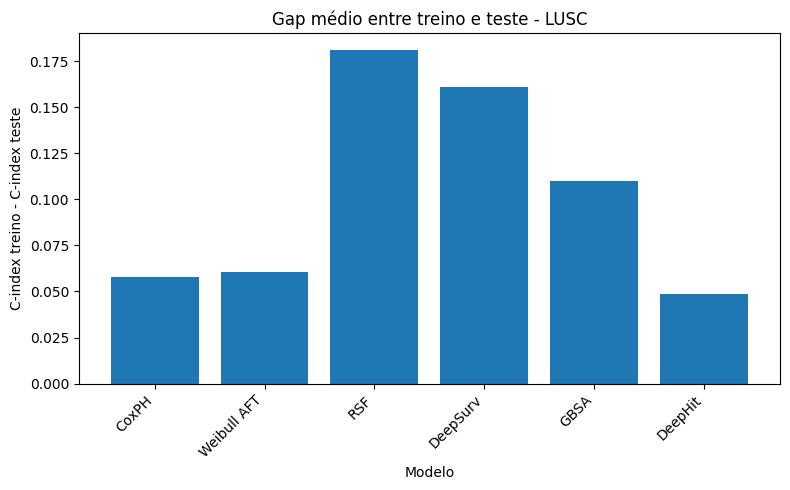

/workspaces/An-lise-de-Sobrevida/reports/figures/lusc/lusc_gap_modelos.png


In [170]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    tabela_tcc["modelo"],
    tabela_tcc["gap_medio"]
)

ax.set_title("Gap médio entre treino e teste - LUSC")
ax.set_xlabel("Modelo")
ax.set_ylabel("C-index treino - C-index teste")

plt.xticks(rotation=45, ha="right")

fig.tight_layout()

fig.savefig(
    figures_dir / "lusc_gap_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(figures_dir / "lusc_gap_modelos.png")

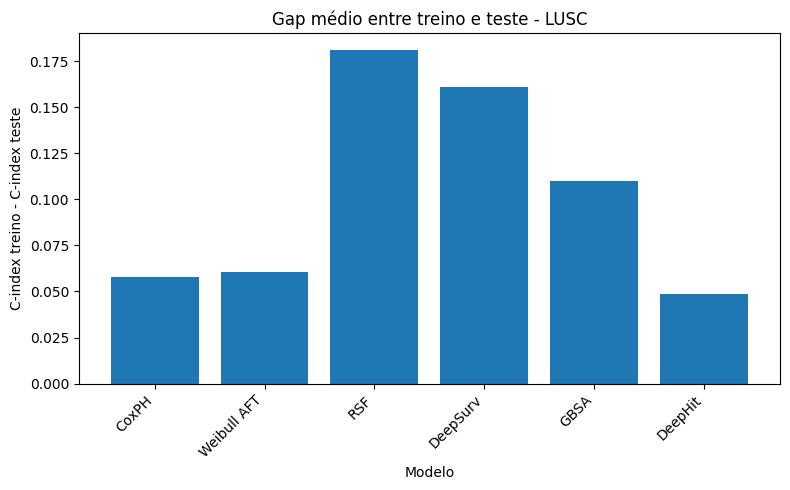

/workspaces/An-lise-de-Sobrevida/reports/figures/lusc/lusc_gap_modelos.png


In [171]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    tabela_tcc["modelo"],
    tabela_tcc["gap_medio"]
)

ax.set_title("Gap médio entre treino e teste - LUSC")
ax.set_xlabel("Modelo")
ax.set_ylabel("C-index treino - C-index teste")

plt.xticks(rotation=45, ha="right")

fig.tight_layout()

fig.savefig(
    figures_dir / "lusc_gap_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(figures_dir / "lusc_gap_modelos.png")

In [172]:
hiperparametros = pd.DataFrame([
    {
        "modelo": "CoxPH",
        "configuracao": "penalizer=1.0; scaler=True; variance_threshold=0.01; corr_threshold=0.90"
    },
    {
        "modelo": "Weibull AFT",
        "configuracao": "penalizer=1.0; scaler=True; variance_threshold=0.01; corr_threshold=0.90"
    },
    {
        "modelo": "RSF",
        "configuracao": "n_estimators=200; min_samples_split=20; min_samples_leaf=15; max_features=sqrt; max_depth=10; corr_threshold=0.95"
    },
    {
        "modelo": "GBSA",
        "configuracao": "n_estimators=100; learning_rate=0.02; max_depth=1; subsample=0.7; corr_threshold=0.90"
    },
    {
        "modelo": "DeepSurv",
        "configuracao": "MLP=[32,16]; dropout=0.1; batch_size=32; epochs=100; lr=0.001; early_stopping=10"
    },
    {
        "modelo": "DeepHit",
        "configuracao": "MLP=[32,16]; num_durations=30; alpha=0.5; sigma=0.1; batch_size=32; epochs=200; lr=0.001; early_stopping=10"
    },
])

hiperparametros

hiperparametros.to_csv(
    results_dir / "lusc_hiperparametros.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

In [173]:
print("FINAL - MODELOS LUSC")

print("Base usada:", data_path)
print("Shape final:", df.shape)
print("Quantidade de features:", X.shape[1])
print("Quantidade de pacientes:", X.shape[0])
print("Eventos:", int(evento.sum()))
print("Taxa de eventos:", round(evento.mean() * 100, 2), "%")

print("Resultados:")
for arquivo in sorted(results_dir.glob("*.csv")):
    print("-", arquivo.name)

print("Figuras :")
for figura in sorted(figures_dir.glob("*.png")):
    print("-", figura.name)

FINAL - MODELOS LUSC
Base usada: /workspaces/An-lise-de-Sobrevida/data/processed/lusc/lusc_modeling_dataset.csv
Shape final: (494, 60)
Quantidade de features: 58
Quantidade de pacientes: 494
Eventos: 212
Taxa de eventos: 42.91 %
Resultados:
- lusc_hiperparametros.csv
- lusc_resultados_por_fold.csv
- lusc_resumo_modelos.csv
Figuras :
- lusc_cindex_modelos.png
- lusc_clinical_profile.png
- lusc_gap_modelos.png
- lusc_kaplan_meier.png
